In [23]:
import pandas as pd
from festival_analysis.analysis_utils import query_db, jaccard_similarity
from itertools import combinations, zip_longest
import seaborn as sns
from matplotlib import pyplot as plt
from tabulate import tabulate

In [2]:
query_lineups = """
SELECT
  festival_id||'-'||edition_year||'-'||artist_id AS entry_id,
  CAST(festival_id AS VARCHAR) AS festival_id,
  festival_id||'-'||edition_year AS edition_id,
  festival_name,
  size_band,
  edition_year,
  location_country,
  CAST(artist_id AS VARCHAR) AS artist_id,
  display_name,
  artist_country,
  ra_status
FROM
  edition_lineups
-- Look onwards from 2015 without lockdown years
WHERE 
  edition_year >= 2015 
  AND edition_year NOT IN (2020, 2021)
"""

df_lineups = query_db(query_lineups, index="entry_id")
df_lineups.info()
df_lineups.head()

<class 'pandas.core.frame.DataFrame'>
Index: 44059 entries, 1199349725585256505-2019-8318369535043110319 to 8578965883151947907-2023-807078318825952979
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   festival_id       44059 non-null  object
 1   edition_id        44059 non-null  object
 2   festival_name     44059 non-null  object
 3   size_band         44059 non-null  object
 4   edition_year      44059 non-null  int32 
 5   location_country  44059 non-null  object
 6   artist_id         44059 non-null  object
 7   display_name      44059 non-null  object
 8   artist_country    42476 non-null  object
 9   ra_status         43193 non-null  object
dtypes: int32(1), object(9)
memory usage: 3.5+ MB


,festival_id,edition_id,festival_name,size_band,edition_year,location_country,artist_id,display_name,artist_country,ra_status
entry_id,,,,,,,,,,
1199349725585256505-2019-8318369535043110319,1199349725585256505,1199349725585256505-2019,Botanica,1 - XS,2019,SE,8318369535043110319,Daniel Bertholdsson,SE,REGIONAL
4055810461483921623-2018-8558387263205314140,4055810461483921623,4055810461483921623-2018,Brunch Electronik,4 - L,2018,ES,8558387263205314140,Loco Dice,TN,TOP1000
5635464652128728794-2017-1420133769443909224,5635464652128728794,5635464652128728794-2017,Field Maneuvers,1 - XS,2017,GB,1420133769443909224,drysu,GB,REGIONAL
5635464652128728794-2025-1420133769443909224,5635464652128728794,5635464652128728794-2025,Field Maneuvers,1 - XS,2025,GB,1420133769443909224,drysu,GB,REGIONAL
1642498070417834405-2018-8015700964355327602,1642498070417834405,1642498070417834405-2018,Het Systeem,1 - XS,2018,NL,8015700964355327602,DVS1,US,TOP1000


In [3]:
df_festival_stats = df_lineups.groupby('festival_id').agg(
    {'festival_name': pd.Series.mode,
    'size_band': pd.Series.mode,
    'location_country': pd.Series.mode,}
)
df_festival_stats

,festival_name,size_band,location_country
festival_id,,,
1082689011160469009,Naturalis,1 - XS,IT
1199349725585256505,Botanica,1 - XS,SE
1311579144894607994,Baltic Weekender,2 - S,GB
1336484889209428545,Accidental Meetings,1 - XS,GB
1457418356257237432,De Weide,1 - XS,NL
...,...,...,...
8868442761932147185,Lentekabinet,2 - S,NL
8969544748426605587,Lighthouse,2 - S,HR
8982369933757010704,Horst,3 - M,BE


In [4]:
festival_name_map = df_festival_stats['festival_name'].to_dict()
artist_name_map = df_lineups[['artist_id', 'display_name']].set_index('artist_id')['display_name'].to_dict()

In [5]:
n_festivals = 50
top_n_festivals = (
    df_lineups.groupby("festival_id")
    .size()
    .sort_values(ascending=False)[:n_festivals]
    .index
)

In [6]:
n_artists = 200
top_n_artists = (
    df_lineups.groupby('artist_id')
    .size()
    .sort_values(ascending=False)[:n_artists]
    .index
)

In [7]:
df_lineups = df_lineups[df_lineups['artist_id'].isin(top_n_artists)]

In [30]:
def festival_similarity(fid1: str, fid2: str, df_lineups: pd.DataFrame) -> tuple:
    artists1 = set(df_lineups[df_lineups['festival_id'] == fid1]['artist_id'])
    artists2 = set(df_lineups[df_lineups['festival_id'] == fid2]['artist_id'])
    jaccard = jaccard_similarity(artists1, artists2)
    return (fid1, fid2, jaccard)


def df_similarities(df_lineups: pd.DataFrame, df_festival_stats: pd.DataFrame) -> pd.DataFrame:
    festival_pairs = combinations(df_lineups['festival_id'].unique(), 2)
    similarity_results = [festival_similarity(fid1, fid2, df_lineups=df_lineups) for fid1, fid2 in festival_pairs]
    df_similarities = pd.DataFrame(similarity_results, columns=['festival_id1', 'festival_id2', 'jaccard_similarity'])
    df_similarities = df_similarities.merge(df_festival_stats.add_suffix('1'), how='left', left_on='festival_id1', right_index=True)
    df_similarities = df_similarities.merge(df_festival_stats.add_suffix('2'), how='left', left_on='festival_id2', right_index=True)
    return df_similarities


def show_similarity(fid1: str, fid2: str, df_lineups: pd.DataFrame, festival_name_map: dict, artist_name_map: dict) -> None:
    artists_1 = set(df_lineups[df_lineups['festival_id'] == fid1]['artist_id'])
    artists_2 = set(df_lineups[df_lineups['festival_id'] == fid2]['artist_id'])

    intersection = artists_1.intersection(artists_2)
    only1 = artists_1.difference(artists_2)
    only2 = artists_2.difference(artists_1)

    print(f'Similarity report between {fid1} - {festival_name_map[fid1]} and {fid2} - {festival_name_map[fid2]}')
    print(f'{len(intersection)} artists playing at both, {len(only1)} only playing at {festival_name_map[fid1]}, {len(only2)} only playing at {festival_name_map[fid2]}')
    table = list(zip_longest([artist_name_map[aid] for aid in intersection], [artist_name_map[aid] for aid in only1], [artist_name_map[aid] for aid in only2], fillvalue=""))
    print(tabulate(table, headers=['Intersection', f'Only playing at {festival_name_map[fid1]}', f'Only playing at {festival_name_map[fid2]}']))



In [9]:
df_similarities = df_similarities(df_lineups=df_lineups, df_festival_stats=df_festival_stats)

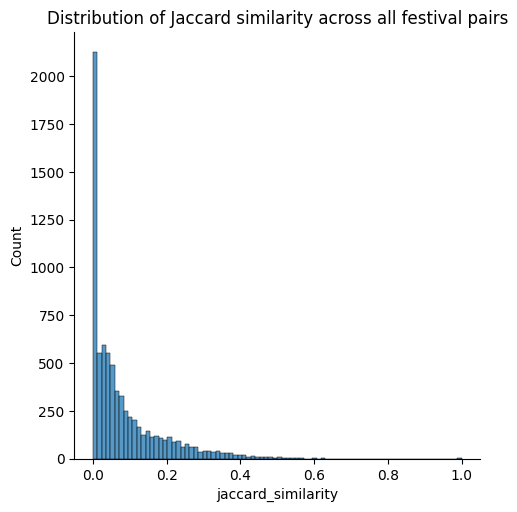

In [10]:
sns.displot(df_similarities['jaccard_similarity'])
plt.title('Distribution of Jaccard similarity across all festival pairs')
plt.show()

In general, festivals are pretty unique across the whole dataset. 

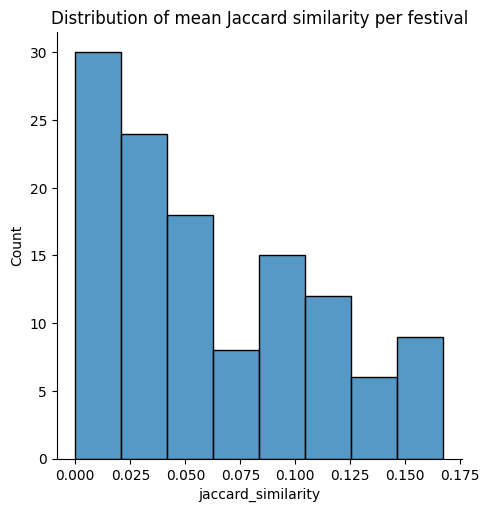

In [11]:
mean_similarities = df_similarities.groupby('festival_id1')['jaccard_similarity'].mean()
sns.displot(mean_similarities)
plt.title('Distribution of mean Jaccard similarity per festival')
plt.show()

Again, very unique (Jaccard is between 0 - no similarity, and 1 - full match)

In [12]:
df_similarities_top_n_festivals = df_similarities[
    (df_similarities['festival_id1'].isin(top_n_festivals))
    & (df_similarities['festival_id2'].isin(top_n_festivals))
]

In [34]:
df_similarities_top_n_festivals.sort_values('jaccard_similarity', ascending=False).head(30)[['festival_name1', 'festival_name2', 'jaccard_similarity']]

,festival_name1,festival_name2,jaccard_similarity
4876,Horst,Dekmantel,0.623457
3604,Dimensions,Dekmantel,0.604651
3323,Lost Village,DGTL,0.566667
3427,Polifonic,Dekmantel,0.565217
132,Love International,Gala,0.562500
4893,Horst,Dekmantel Selectors,0.559055
2179,Draaimolen,Dekmantel,0.556962
3602,Dimensions,Horst,0.556250
3946,DGTL,Dekmantel,0.556180
4108,Houghton,Gottwood,0.546875


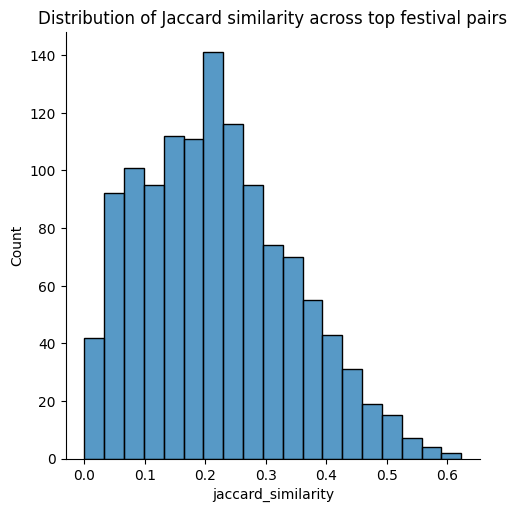

In [19]:
sns.displot(df_similarities_top_n_festivals['jaccard_similarity'])
plt.title('Distribution of Jaccard similarity across top festival pairs')
plt.show()

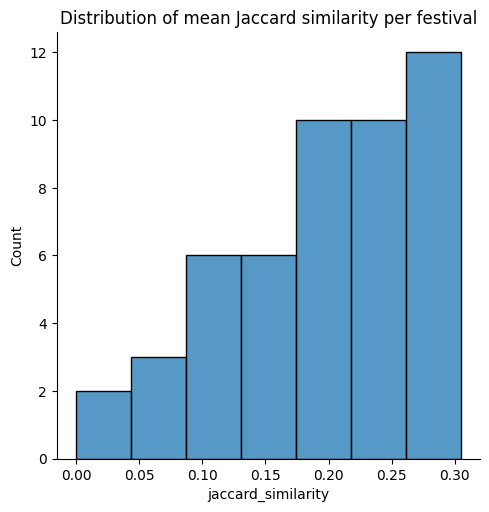

In [20]:
mean_similarities = df_similarities_top_n_festivals.groupby('festival_id1')['jaccard_similarity'].mean()
sns.displot(mean_similarities)
plt.title('Distribution of mean Jaccard similarity per festival')
plt.show()

In [31]:
show_similarity('8982369933757010704', '8578965883151947907', df_lineups=df_lineups, festival_name_map=festival_name_map, artist_name_map=artist_name_map)

Similarity report between 8982369933757010704 - Horst and 8578965883151947907 - Dekmantel
101 artists playing at both, 17 only playing at Horst, 44 only playing at Dekmantel
Intersection              Only playing at Horst    Only playing at Dekmantel
------------------------  -----------------------  ---------------------------
Roza Terenzi              Leon Vynehall            KiNK
CEM                       Lola Haro                Mary Lake
ISAbella                  Unai Trotti              Carlos Valdes
Mama Snake                KI/KI                    Pangaea
Peach                     Axel Boman               Interplanetary Criminal
PARAMIDA                  The Ghost                Paranoid London
D. Tiffany                Angel D'lite             CARISTA
Mia Koden                 Sally C                  Pearson Sound
SPFDJ                     Radioactive Man          Jeff Mills
Christian AB              Danielle                 Nina Kraviz
JASSS                     CC:DISCO!   

In [32]:
show_similarity('3602738408784743846', '5837716347545413629', df_lineups=df_lineups, festival_name_map=festival_name_map, artist_name_map=artist_name_map)

Similarity report between 3602738408784743846 - Houghton and 5837716347545413629 - Gottwood
70 artists playing at both, 22 only playing at Houghton, 36 only playing at Gottwood
Intersection         Only playing at Houghton    Only playing at Gottwood
-------------------  --------------------------  --------------------------
Harri Pepper         Pangaea                     Leon Vynehall
Dave Harvey          CARISTA                     Roza Terenzi
Paranoid London      Pearson Sound               Young Marco
Sugar Free           Or:la                       KiNK
Prosumer             Vlada                       Interplanetary Criminal
Move D               Surgeon                     Doudou MD
Ogazón               Lena Willikens              Sweely
The Ghost            Optimo (Espacio)            Octo Octa
Palms Trax           DJ Stingray 313             Blawan
Dr Banana            Jen Cardini                 Paquita Gordon
Tristan da Cunha     Vladimir Ivkovic            Bambounou
Daniell